## Problem 1
### Part 1

In [2]:
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff, eye
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import init_printing
init_printing() 

# Define Symbols
t  = symbols("t",   real=True)
l = symbols("l",  real=True)   # Length of Link, assume Links are same length
m = symbols("m", real=True)
k = symbols("k", real=True) # Drag Coefficient
d = symbols("d",real=True)
# Config Variables
x     = Function('x',     real=True)(t)
y     = Function('y',     real=True)(t)
theta = Function('theta', real=True)(t)
a1    = Function('a1',real=True)(t)
a2    = Function('a2',real=True)(t)
## Alpha Kinematics
omega = symbols("omega",real=True)
A1 = symbols("A1",real=True)
A2 = symbols("A2",real=True)
phi = symbols("phi",real=True)


In [3]:
# Defining Various Helper Functions
def cross_matrix(vec):
    
    return Matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return Matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return(m)
    
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])

def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m


In [34]:
# Transform to Joint 1, then Translate to COM 1
T0COM1   = T(R_z(theta), Matrix([[x],[y],[0]]))
#TJ1toCOM1 = T(eye(3), Matrix([[l/2],[0],[0]]))
#T1 = simplify(Tjoint1 @ TJ1toCOM1) # World Frame to COM 1

T1J1= T(eye(3), Matrix([[-l/2],[0],[0]]))
TJ1rot = T(R_z(pi-a1),Matrix([[-l/2],[0],[0]]))
TJ1COM2 = T(eye(3),Matrix([[-l/2],[0],[0]]))
T0COM2= simplify(T0COM1 @ T1J1 @ TJ1rot @ TJ1COM2)

T1J2= T(eye(3),Matrix([[l/2],[0],[0]]))
TJ2rot = (T(R_z(a2),Matrix([[l/2],[0],[0]])))
TJ2COM3 = T(eye(3),Matrix([[l/2],[0],[0]]))
T0COM3= simplify(T0COM1 @ T1J2 @ TJ2rot @ TJ2COM3)
##


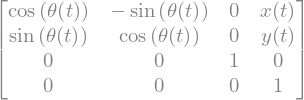

In [35]:
T0COM1

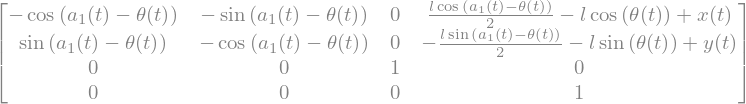

In [36]:
T0COM2

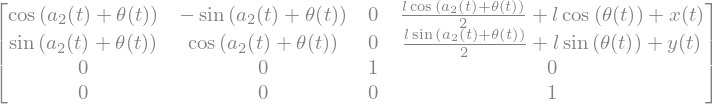

In [37]:
T0COM3

### Part 2 Compute Body Twists for each COM

In [38]:
# Define q, qdt, qdtdt
q= [x,y,theta,a1,a2]
q_dt= [Derivative(qq,t) for qq in q]
q_dtdt= [Derivative(qq,t,t) for qq in q]

# Body Twist For Each COM
bodytwist_COM1 = simplify(T0COM1.inv() @ diff(T0COM1, t))
bodytwist_COM1 = twist2vec(bodytwist_COM1) # Vectorized Bodytwist for COM 1
bodytwist_COM2 = simplify(T0COM2.inv() @ diff(T0COM2, t))
bodytwist_COM2 = twist2vec(bodytwist_COM2) # Vectorized Bodytwist for COM 2
bodytwist_COM3 = simplify(T0COM3.inv() @ diff(T0COM3, t))
bodytwist_COM3 = twist2vec(bodytwist_COM3) # Vectorized Bodytwist for COM 3

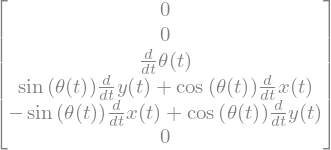

In [39]:
bodytwist_COM1

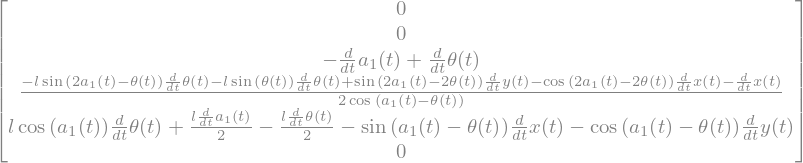

In [40]:
bodytwist_COM2

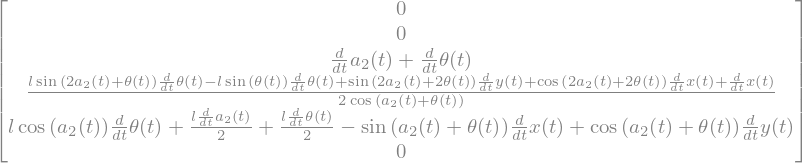

In [41]:
bodytwist_COM3

### Part 3 Compute Jacobian

In [42]:
# Body Twist Jacobians
J1 = bodytwist_COM1.jacobian(q_dt)
J2 = bodytwist_COM2.jacobian(q_dt)
J3 = bodytwist_COM3.jacobian(q_dt)

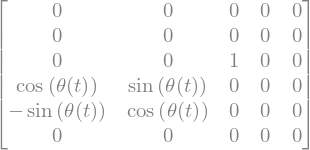

In [43]:
J1

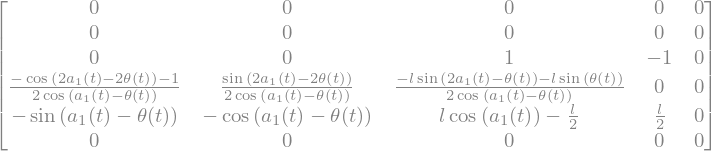

In [44]:
J2

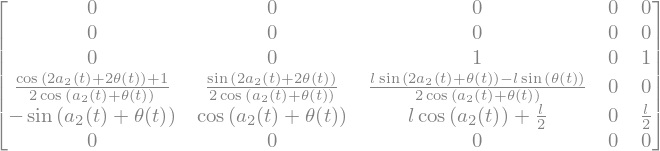

In [45]:
J3

### Part 4 Body Wrench

In [46]:
# Viscous Force Matrix
B = Matrix([
    [0, 0,        0, 0,   0,   0],
    [0, 0,        0, 0,   0,   0],
    [0, 0, 2/3*k*l**3, 0,   0,   0],
    [0, 0,        0, k*l, 0,   0],
    [0, 0,        0, 0, 2*k*l, 0],
    [0, 0,        0, 0,   0,   0]
])
def BodyWrench(bodytwist):
    return -B @ bodytwist

# Call BodyWrenches
F1 = BodyWrench(simplify(bodytwist_COM1))
F2 = simplify(BodyWrench(bodytwist_COM2))
F3 = BodyWrench(simplify(bodytwist_COM3))

A = J1.T @ B @ J1 + J2.T @ B @ J2 + J3.T @ B @ J3

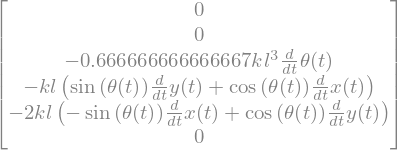

In [47]:
F1

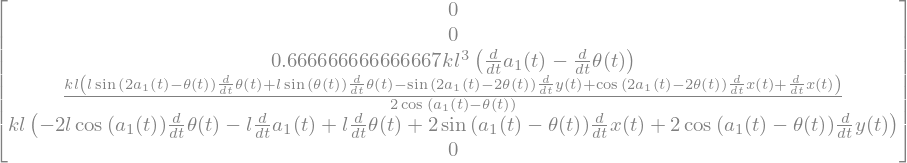

In [48]:
F2

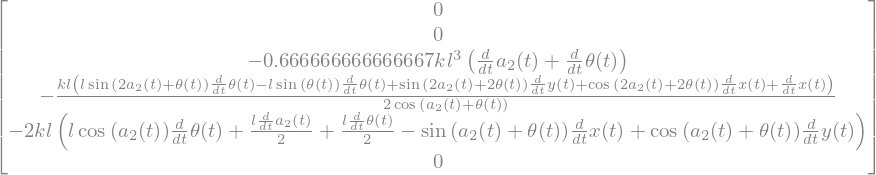

In [49]:
F3

### Part 5

In [50]:
params = [l,m,k,A1,A2,omega,phi]
def dynamics(t,state,alpha_fcn,params):
    x,y,theta = state
    l, m, k, A1, A2, omega, phi = params
    a1, a2, a1_dt, a2_dt = alpha_fcn(t, omega, A1, A2, phi)  
    q_ = [x,y,theta,a1,a2]
    q_dt_= [0,0,0,0,0]
    
    dydt= Vb(t,q_,q_dt_,params_) @ np.matrix(([a1_dt],[a2_dt]))
    
    return dydt.flatten().tolist()[0]

### Part 6

In [51]:
# Extract submatrices
A11_sym = A[0:3, 0:3]
A12_sym = A[0:3, 3:]
A21_sym = A[3:, 0:3]
A22_sym = A[3:, 3:]

A11_lam= lambdify([t,q,q_dt,params],A11_sym)
A12_lam= lambdify([t,q,q_dt,params],A12_sym)

In [52]:
params_=[1,1,1,1,1,1,1]
q_ = [0,0,0,0, np.pi/8]
q_dt_=[0,0,0,0,0]
np.linalg.inv(A11_lam(0,q_,q_dt_,params_))

array([[ 0.32670069,  0.00960757,  0.03334455],
       [ 0.00960757,  0.18608316, -0.04830052],
       [ 0.03334455, -0.04830052,  0.16569895]])

In [53]:
def Vb(t,q,q_dt,params):
    return -np.linalg.inv(A11_lam(0,q,q_dt,params)) @ A12_lam(0,q,q_dt,params)

In [54]:
B(0,q_,q_dt_,params_)

TypeError: 'MutableDenseMatrix' object is not callable

In [55]:
alpha_fcn

<function _lambdifygenerated(t, omega, A1, A2, phi)>

### Part 7

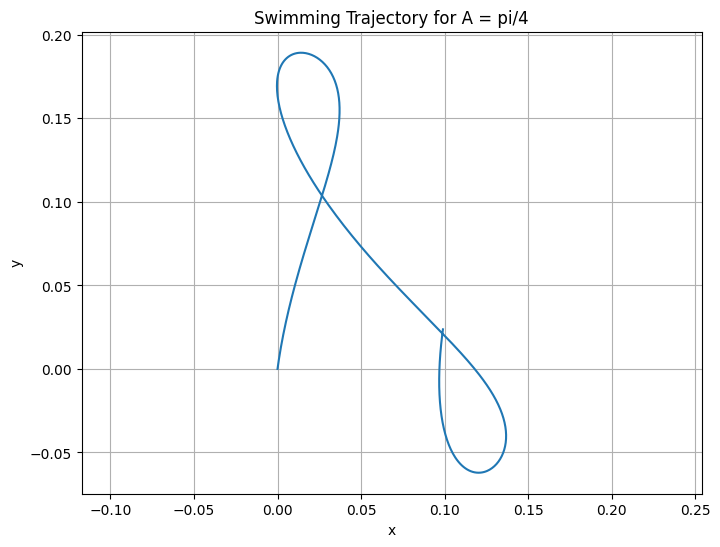

In [56]:
# Part 7 - Simulate Swimming with A = pi/4
# Gait Function
alpha_fcn = lambdify((t, omega, A1, A2, phi),[A1*sin(omega*t),
                                 A2*sin(omega*t +phi),
                                 diff(A1*sin(omega*t),t),
                                 diff(A2*sin(omega*t + phi),t)])
l_=1
m_=1
k_=1
A_amp = float(pi/4)
A1_ = A_amp
A2_ = A_amp
phi_    = float(np.pi/2)
omega_=float(2*np.pi)
params_ = [l_, m_, k_, A1_, A2_, omega_, phi_]

# Initial conditions [x, y, theta, a1, a2]
y0     = [0, 0, 0]
t_span = (0, 1)
t_eval = np.linspace(0, 1, 500)

# Solve
sol = solve_ivp(
    lambda t, y: dynamics(t, y, alpha_fcn, params_),
    t_span,
    y0,
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-8
)
# Plot x,y trajectory
plt.figure(figsize=(8, 6))
plt.plot(sol.y[0], sol.y[1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Swimming Trajectory for A = pi/4')
plt.axis('equal')
plt.grid(True)
plt.show()

In [59]:
sol.y[0] = x
sol.y[1] = y
sol.y[2] = theta
import matplotlib.pyplot as plt

theta = sol.y[2, :]
x = sol.y[0, :]
y = sol.y[1, :]

# --- x vs theta ---
plt.figure()
plt.plot(theta, x)
plt.xlabel(r'$\theta$')
plt.ylabel('x')
plt.title('x vs θ')
plt.grid(True)

# --- y vs theta ---
plt.figure()
plt.plot(theta, y)
plt.xlabel(r'$\theta$')
plt.ylabel('y')
plt.title('y vs θ')
plt.grid(True)

plt.show()

TypeError: Cannot convert expression to float

### Part 8

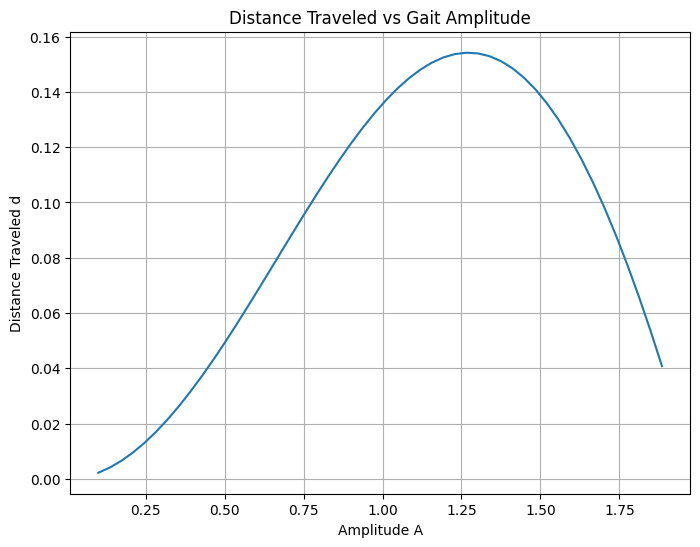

In [57]:
# Part 8 - Sweep Amplitude from 0.1 to 1.2*pi/2
A_vals    = np.linspace(0.1, 1.2*np.pi/2, 50)
distances = []
phi_val   = float(pi/2)

A_vals = np.linspace(0.1, 1.2*np.pi/2, 50)
distances = []

phi_ = float(pi/2)

for A1_ in A_vals:

    # 1. build parameters
    A2_ = A1_
    params_ = [l_, m_, k_, A1_, A2_, omega_, phi_]

    # 2. time setup
    init_state = [0, 0, 0]
    t_end = 1
    dt = 0.01
    time = np.linspace(0, t_end, int(t_end/dt))

    # 3. solve ODE
    sol = solve_ivp(
        lambda t, y: dynamics(t, y, alpha_fcn, params_),
        (0, t_end),
        init_state,
        t_eval=time,
        rtol=1e-8,
        atol=1e-8
    )

    # 4. recompute velocities (like screenshot does)
    q_dots = np.zeros((3, len(time)))

    for i, ti in enumerate(time):
        q_dots[:, i] = dynamics(ti, sol.y[:, i], alpha_fcn, params_)

    # 5. extract final position
    x_sol = sol.y[0, :]
    y_sol = sol.y[1, :]

    d = np.sqrt(x_sol[-1]**2 + y_sol[-1]**2)
    distances.append(d)
# Plot distance vs amplitude
plt.figure(figsize=(8, 6))
plt.plot(A_vals, distances)
plt.xlabel('Amplitude A')
plt.ylabel('Distance Traveled d')
plt.title('Distance Traveled vs Gait Amplitude')
plt.grid(True)
plt.show()

## Problem 2


In [23]:
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff, eye
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import init_printing
init_printing() 

# Define Symbols
t  = symbols("t",   real=True)
l = symbols("l",  positive=True)   # Length of Link, assume Links are same length
#l2 = symbols("l2",  positive=True)   # Length of Link 2
#l3 = symbols("l3",  positive=True)   # Lrngth of link 3
k = symbols("k", positive=True) # Drag Coefficient
# Config Variables
x     = Function('x',     real=True)(t)
y     = Function('y',     real=True)(t)
theta = Function('theta', real=True)(t)
a1    = Function('a1',real=True)(t)
a2    = Function('a2',real=True)(t)
# Defining Various Helper Functions
def cross_matrix(vec):
    
    return Matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return Matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return(m)
    
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])

def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m


### Part 1

In [24]:
def body_wrench_from_friction(V_b, f_par=1.0, f_lat=2.0):
    """
    F_b = -B @ V_b
    
    B = diag(c_x, f_lat, f_lat)
    where c_x = 2*f_par if sliding backward (vx < 0), else f_par
    """
    V_b = np.asarray(V_b, dtype=float)
    vx  = V_b[0]

    cx = 2.0 * f_par if vx < 0 else f_par
    B  = np.diag([cx, f_lat, f_lat])

    return -B @ V_b

In [31]:
from scipy.spatial.transform import Rotation
 
def rotation_matrix_2d(theta):
    """2D rotation matrix R(theta)."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]])
 
def body_jacobian_link(q, link_idx, L=1.0):
    """
    Compute the body Jacobian J_i for link i of a 3-link planar swimmer.
 
    State vector q = [x, y, theta, alpha1, alpha2]
      x, y, theta : pose of the base (link 0) in world frame
      alpha1      : joint angle between link 0 and link 1
      alpha2      : joint angle between link 1 and link 2
 
    Each link has length L.
    The body twist of link i is V_b_i = J_i(q) * q_dot.
 
    We use the convention that the body frame of each link is at its center.
    """
    x, y, theta, a1, a2 = q
 
    # Absolute orientations
    th0 = theta
    th1 = theta + a1
    th2 = theta + a1 + a2
 
    # Link center positions (world frame), measured from base origin
    c0 = np.array([x, y]) + L/2 * np.array([np.cos(th0), np.sin(th0)])
    c1 = (np.array([x, y])
          + L * np.array([np.cos(th0), np.sin(th0)])
          + L/2 * np.array([np.cos(th1), np.sin(th1)]))
    c2 = (np.array([x, y])
          + L * np.array([np.cos(th0), np.sin(th0)])
          + L * np.array([np.cos(th1), np.sin(th1)])
          + L/2 * np.array([np.cos(th2), np.sin(th2)]))
 
    centers = [c0, c1, c2]
    thetas  = [th0, th1, th2]
 
    ci  = centers[link_idx]
    thi = thetas[link_idx]
    Ri  = rotation_matrix_2d(thi)   # world ← body
 
    # Body Jacobian: maps q_dot → body twist [vx_b, vy_b, omega_b]
    # q = [x, y, theta, a1, a2], so J is 3×5
    J = np.zeros((3, 5))
 
    # Translational part in world frame, then rotate to body frame
    # d(ci)/d(q_k) gives world-frame velocity contribution
    # body velocity vb = R^T * (world velocity of ci - omega × r_offset)
    # For planar: vb_xy = R^T * dci/dqk * qdotk, omega_b = d(thi)/dqk * qdotk
 
    # --- d ci / d q ---
    if link_idx == 0:
        # c0 = [x + L/2 cos(th0), y + L/2 sin(th0)]
        dcx = np.zeros(5); dcy = np.zeros(5)
        dcx[0] = 1.0;  dcy[1] = 1.0   # d/dx, d/dy
        dcx[2] = -L/2 * np.sin(th0);  dcy[2] = L/2 * np.cos(th0)
        dth = np.zeros(5); dth[2] = 1.0
    elif link_idx == 1:
        dcx = np.zeros(5); dcy = np.zeros(5)
        dcx[0] = 1.0;  dcy[1] = 1.0
        dcx[2] = -L*np.sin(th0) - L/2*np.sin(th1)
        dcy[2] =  L*np.cos(th0) + L/2*np.cos(th1)
        dcx[3] = -L/2*np.sin(th1)
        dcy[3] =  L/2*np.cos(th1)
        dth = np.zeros(5); dth[2] = 1.0; dth[3] = 1.0
    else:  # link_idx == 2
        dcx = np.zeros(5); dcy = np.zeros(5)
        dcx[0] = 1.0;  dcy[1] = 1.0
        dcx[2] = -L*np.sin(th0) - L*np.sin(th1) - L/2*np.sin(th2)
        dcy[2] =  L*np.cos(th0) + L*np.cos(th1) + L/2*np.cos(th2)
        dcx[3] = -L*np.sin(th1) - L/2*np.sin(th2)
        dcy[3] =  L*np.cos(th1) + L/2*np.cos(th2)
        dcx[4] = -L/2*np.sin(th2)
        dcy[4] =  L/2*np.cos(th2)
        dth = np.zeros(5); dth[2] = 1.0; dth[3] = 1.0; dth[4] = 1.0
 
    # Rotate to body frame: [vbx; vby] = R^T * [vcx; vcy]
    Rt = Ri.T
    J[0, :] = Rt[0, 0] * dcx + Rt[0, 1] * dcy
    J[1, :] = Rt[1, 0] * dcx + Rt[1, 1] * dcy
    J[2, :] = dth
 
    return J
 
 
def net_force_snake_friction(q, q_dot, L=1.0, f_par=1.0, f_lat=2.0):
    """
    Compute the net generalized force vector on the 3-link swimmer
    due to snake-skin friction.
 
    τ = -Σ_i J_i^T(q) F_b_i(V_b_i)
 
    where V_b_i = J_i(q) * q_dot
 
    Parameters
    ----------
    q     : array (5,) – [x, y, theta, alpha1, alpha2]
    q_dot : array (5,) – time derivative of q
    L     : link length
    f_par, f_lat : friction coefficients
 
    Returns
    -------
    tau : array (5,) – generalized forces
    """
    q     = np.asarray(q, dtype=float)
    q_dot = np.asarray(q_dot, dtype=float)
    tau   = np.zeros(5)
 
    for i in range(3):
        Ji   = body_jacobian_link(q, i, L=L)
        Vbi  = Ji @ q_dot
        Fbi  = body_wrench_from_friction(Vbi, f_par=f_par, f_lat=f_lat)
        tau += Ji.T @ Fbi   # note: already negated inside body_wrench
 
    return tau
 
 
# Quick test
if __name__ == "__main__":
    q_test     = np.array([0., 0., 0., 0.3, -0.3])
    q_dot_test = np.array([0.1, 0., 0., 0.5, -0.5])
    print("\nCell 2 – net generalized force:")
    print("  tau =", net_force_snake_friction(q_test, q_dot_test))


Cell 2 – net generalized force:
  tau = [ 0.03454709 -1.40477261 -4.04378479 -2.63901218 -0.47766824]


### Part 2

In [32]:
# =============================================================================
# CELL 2: Body Jacobians and net generalized force
# =============================================================================

def get_link_transform(q, link_idx, L=1.0):
    """
    World-frame transform T_i for the CENTER of link i,
    built using the T() and R_z() helpers from the setup.
    
    q = [x, y, theta, a1, a2]
    """
    x, y, theta, a1, a2 = q

    # Base frame at origin of link 0
    T_world = T(R_z(theta), Matrix([x, y, 0]))

    # Each joint adds a rotation + translation of length L along x
    T_01 = T(R_z(a1), Matrix([L, 0, 0]))   # joint 1: end of link 0
    T_12 = T(R_z(a2), Matrix([L, 0, 0]))   # joint 2: end of link 1

    # Half-link offset to reach link center
    T_half = T(eye(3), Matrix([L/2, 0, 0]))

    if link_idx == 0:
        T_center = T_world @ T_half
    elif link_idx == 1:
        T_center = T_world @ T_01 @ T_half
    else:
        T_center = T_world @ T_01 @ T_12 @ T_half

    return np.array(T_center.tolist(), dtype=float)


def body_jacobian_link(q, link_idx, L=1.0):
    """
    Body Jacobian J_i (3×5) for link i: maps q_dot → body twist [vx_b, vy_b, omega_b].
    
    Uses get_link_transform() to get R_i and p_i, then builds
    the geometric Jacobian and rotates to body frame via R_i^T.
    """
    q = np.asarray(q, dtype=float)
    x, y, theta, a1, a2 = q

    th0 = theta
    th1 = theta + a1
    th2 = theta + a1 + a2

    # Get this link's world transform
    Ti  = get_link_transform(q, link_idx, L=L)
    Ri  = Ti[:3, :3]          # world ← body rotation (3×3, but planar so use [:2,:2])
    pi  = Ti[:2,  3]          # link center in world frame

    # Joint axes (all z-axis for planar) and joint positions in world frame
    # q = [x, y, theta, a1, a2]
    # Prismatic x:  column 0 → [cos(th0), sin(th0), 0] translated velocity
    # Prismatic y:  column 1 → [0 rotated, sin direction]
    # Revolute theta: about joint at [x,y]
    # Revolute a1:    about joint at end of link 0
    # Revolute a2:    about joint at end of link 1

    # Joint origins in world frame
    p_base = np.array([x, y])
    p_j1   = p_base + L * np.array([np.cos(th0), np.sin(th0)])
    p_j2   = p_j1   + L * np.array([np.cos(th1), np.sin(th1)])

    J_world = np.zeros((3, 5))

    # --- Translational DOFs (x, y): pure prismatic ---
    J_world[0, 0] = 1.0   # d(px)/d(x)
    J_world[1, 1] = 1.0   # d(py)/d(y)

    # --- Revolute DOFs: v = z × (p_i - p_joint), omega = 1 ---
    # z-axis = [0, 0, 1], so z × r = [-ry, rx, 0]
    def revolute_col(p_joint):
        r = pi - p_joint          # vector from joint to link center
        return np.array([-r[1], r[0], 1.0])

    J_world[:, 2] = revolute_col(p_base)                     # theta joint

    if link_idx >= 1:
        J_world[:, 3] = revolute_col(p_j1)                   # a1 joint
    if link_idx >= 2:
        J_world[:, 4] = revolute_col(p_j2)                   # a2 joint

    # Rotate translational rows to body frame: v_b = R^T * v_world
    Rt = Ri[:2, :2].T
    J_body        = np.zeros((3, 5))
    J_body[:2, :] = Rt @ J_world[:2, :]   # rotate xy velocity rows
    J_body[2,  :] = J_world[2,  :]        # angular row unchanged

    return J_body


def net_force_snake_friction(q, q_dot, L=1.0, f_par=1.0, f_lat=2.0):
    """τ = Σ_i J_i^T F_b_i,  where F_b_i = -B * (J_i @ q_dot)"""
    q, q_dot = np.asarray(q, float), np.asarray(q_dot, float)
    return sum(
        body_jacobian_link(q, i, L).T @ body_wrench_from_friction(
            body_jacobian_link(q, i, L) @ q_dot, f_par=f_par, f_lat=f_lat)
        for i in range(3)
    )

# Quick test
q_test     = np.array([0., 0., 0., 0.3, -0.3])
q_dot_test = np.array([0.1, 0., 0., 0.5, -0.5])
print("Cell 2 – net generalized force:")
print("  tau =", net_force_snake_friction(q_test, q_dot_test))

Cell 2 – net generalized force:
  tau = [ 0.03454709 -1.40477261 -4.04378479 -2.63901218 -0.47766824]


### Part 3

In [33]:
# =============================================================================
# CELL 3: Solve for V_P via fsolve
# =============================================================================
from scipy.optimize import fsolve

def swimmer_velocity_fsolve(q, alpha_dot, V_P0=None, L=1.0, f_par=1.0, f_lat=2.0):
    """
    Solve A11 * V_P + A12 * alpha_dot = 0  for V_P = [xdot, ydot, thetadot].
    
    V_P0 : optional warm-start initial guess (pass previous solution in Cell 4)
    """
    q         = np.asarray(q,         float)
    alpha_dot = np.asarray(alpha_dot, float)

    def residual(V_P):
        q_dot = np.concatenate([V_P, alpha_dot])
        return net_force_snake_friction(q, q_dot, L=L, f_par=f_par, f_lat=f_lat)[:3]

    V_P_sol, _, ier, msg = fsolve(residual, np.zeros(3) if V_P0 is None else V_P0,
                                  full_output=True)
    if ier != 1:
        print(f"  fsolve warning: {msg}")
    return V_P_sol


# Test on random config
np.random.seed(42)
q_rand    = np.array([0., 0., np.random.uniform(-np.pi, np.pi),
                      np.random.uniform(-1., 1.), np.random.uniform(-1., 1.)])
adot_rand = np.random.uniform(-1., 1., size=2)

V_P = swimmer_velocity_fsolve(q_rand, adot_rand)
print("Cell 3 – swimmer velocity (fsolve)")
print(f"  V_P   = {V_P}")
print(f"  residual = {net_force_snake_friction(np.concatenate([q_rand]), np.concatenate([V_P, adot_rand]))[:3]}")

Cell 3 – swimmer velocity (fsolve)
  V_P   = [-0.04856174 -0.1203313   0.0759871 ]
  residual = [ 1.38777878e-17 -5.55111512e-17  0.00000000e+00]


### Part 4

Integration succeeded: The solver successfully reached the end of the integration interval.


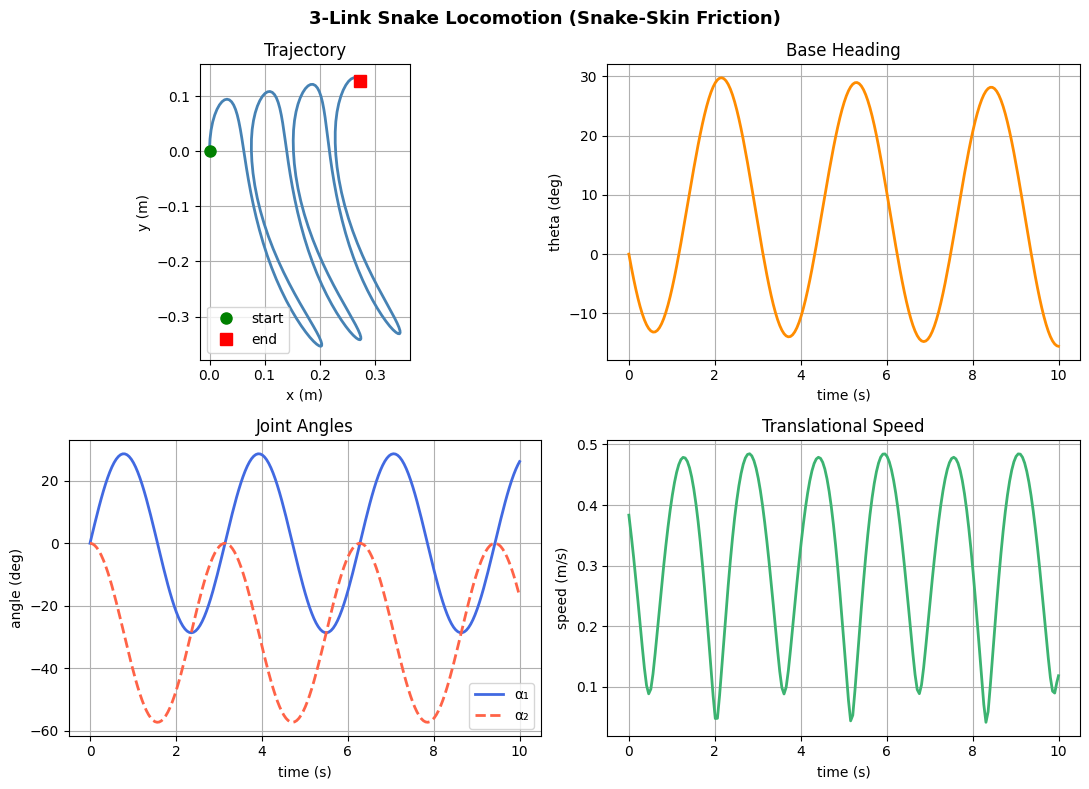

In [34]:
# =============================================================================
# CELL 4: Dynamics + solve_ivp
# =============================================================================

def make_dynamics(omega=1.0, A=0.5, L=1.0, f_par=1.0, f_lat=2.0):
    """
    Returns a dynamics function with a warm-start cache — passes the
    previous V_P solution as the initial guess to fsolve each step.
    """
    V_P_cache = [np.zeros(3)]

    def dynamics(t, state):
        q  = np.asarray(state, float)
        th = q[2]

        alpha_dot = np.array([
            A * omega * np.cos(omega * t),
            A * omega * np.cos(omega * t + np.pi / 2)
        ])

        V_P = swimmer_velocity_fsolve(q, alpha_dot,
                                      V_P0=V_P_cache[0], L=L,
                                      f_par=f_par, f_lat=f_lat)
        V_P_cache[0] = V_P   # update warm-start

        return [V_P[0], V_P[1], V_P[2], alpha_dot[0], alpha_dot[1]]

    return dynamics


A, omega, t_end = 0.5, 2.0, 10.0
state0 = [0., 0., 0., 0., 0.]

sol = solve_ivp(make_dynamics(omega=omega, A=A),
                t_span=(0, t_end), y0=state0,
                method='RK45', max_step=0.05, rtol=1e-4, atol=1e-6)
print(f"Integration {'succeeded' if sol.success else 'FAILED'}: {sol.message}")

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle("3-Link Snake Locomotion (Snake-Skin Friction)", fontsize=13, fontweight='bold')
t_arr = sol.t
x, y, theta, a1, a2 = sol.y

axes[0,0].plot(x, y, 'steelblue', lw=2)
axes[0,0].plot(x[0], y[0], 'go', ms=8, label='start')
axes[0,0].plot(x[-1], y[-1], 'rs', ms=8, label='end')
axes[0,0].set(xlabel='x (m)', ylabel='y (m)', title='Trajectory', aspect='equal')
axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(t_arr, np.rad2deg(theta), color='darkorange', lw=2)
axes[0,1].set(xlabel='time (s)', ylabel='theta (deg)', title='Base Heading')
axes[0,1].grid(True)

axes[1,0].plot(t_arr, np.rad2deg(a1), label='α₁', color='royalblue', lw=2)
axes[1,0].plot(t_arr, np.rad2deg(a2), label='α₂', color='tomato', lw=2, ls='--')
axes[1,0].set(xlabel='time (s)', ylabel='angle (deg)', title='Joint Angles')
axes[1,0].legend(); axes[1,0].grid(True)

speed = np.sqrt(np.gradient(x, t_arr)**2 + np.gradient(y, t_arr)**2)
axes[1,1].plot(t_arr, speed, color='mediumseagreen', lw=2)
axes[1,1].set(xlabel='time (s)', ylabel='speed (m/s)', title='Translational Speed')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()